## Exploratory Data Analysis (EDA)
Initial analysis of the cleaned dataset, aimed at summarizing the data's main characteristics to gain a thorough understanding of the dataset

Load libraries and create path to retail.db database

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
df = pd.read_csv(DATA_PROCESSED / 'retail_clean.csv', parse_dates=['date'])

### Summary Statistics
The following summary statistics were identified:
1. Shape of the data: 3,633 rows, 8 columns
2. Data range:  April 1982-June 2025
3. Categories: 7 categories (incluing 1 total category) with 519 rows each
4. Missing values: 0


In [ ]:

# Shape of data 
shape = df.shape
print(shape)

# Date range
date_range = df['date'].min(), '→', df['date'].max()
print(date_range)

# Categories
categories = df['category'].value_counts()
print(categories)

# Missing values
missing_values = df.isna().sum()
print(missing_values)

# Summary statistics
summary_stats = df.groupby('category')['turnover_m'].describe().round(1)
print(summary_stats)

(3633, 8)
(Timestamp('1982-04-01 00:00:00'), '→', Timestamp('2025-06-01 00:00:00'))
category
Cafes, restaurants and takeaway food services          519
Clothing, footwear and personal accessory retailing    519
Department stores                                      519
Food retailing                                         519
Household goods retailing                              519
Other retailing                                        519
Total (Industry)                                       519
Name: count, dtype: int64
date           0
series_id      0
turnover_m     0
category       0
series_type    0
year           0
month          0
month_name     0
dtype: int64
                                                    count     mean     std  \
category                                                                     
Cafes, restaurants and takeaway food services       519.0   2108.7  1436.5   
Clothing, footwear and personal accessory retai...  519.0   1338.2   784.5   
Departm

### Distribution of turnover by category

This analysis visualizes how overall turnover is distributed by category. This shows which categories may dominate share of the turnover and which categories have a minimal share of turnover

/var/folders/9f/p78d3qk120s30pxsr05rd9500000gn/T/ipykernel_21795/2677004033.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, vert=True)


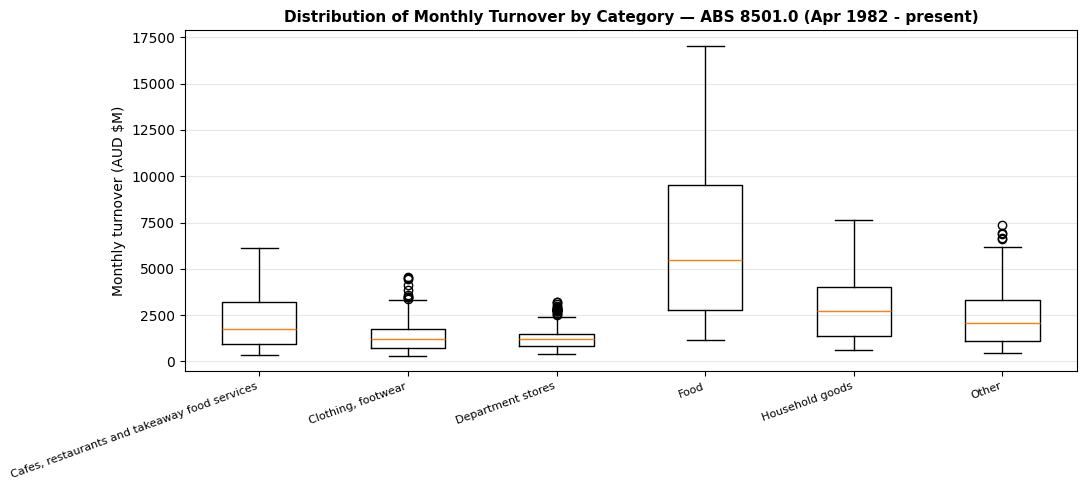

In [ ]:
import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(11, 5))

# Create lists of categories, their respective data, and labels for the figure
cats = df[df['category'] != 'Total (Industry)']
data = [cats[cats['category'] == c]['turnover_m'].values for c in cats['category'].unique()]
labels = [c.replace('retailing','').replace('and personal accessory','').strip() for c in cats['category'].unique()]

ax.boxplot(data, labels=labels, vert=True)
plt.xticks(rotation=20, ha='right', fontsize=8)

# Set labels and title for the figure
ax.set_ylabel('Monthly turnover (AUD $M)')
ax.set_title('Distribution of Monthly Turnover by Category — ABS 8501.0 (Apr 1982 - present)',
fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# Save figure to folder
plt.savefig(PROJECT_ROOT / 'output' / 'eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Timeseries Overview

This analysis visualizes how each category's overall turnover values have progressed over time

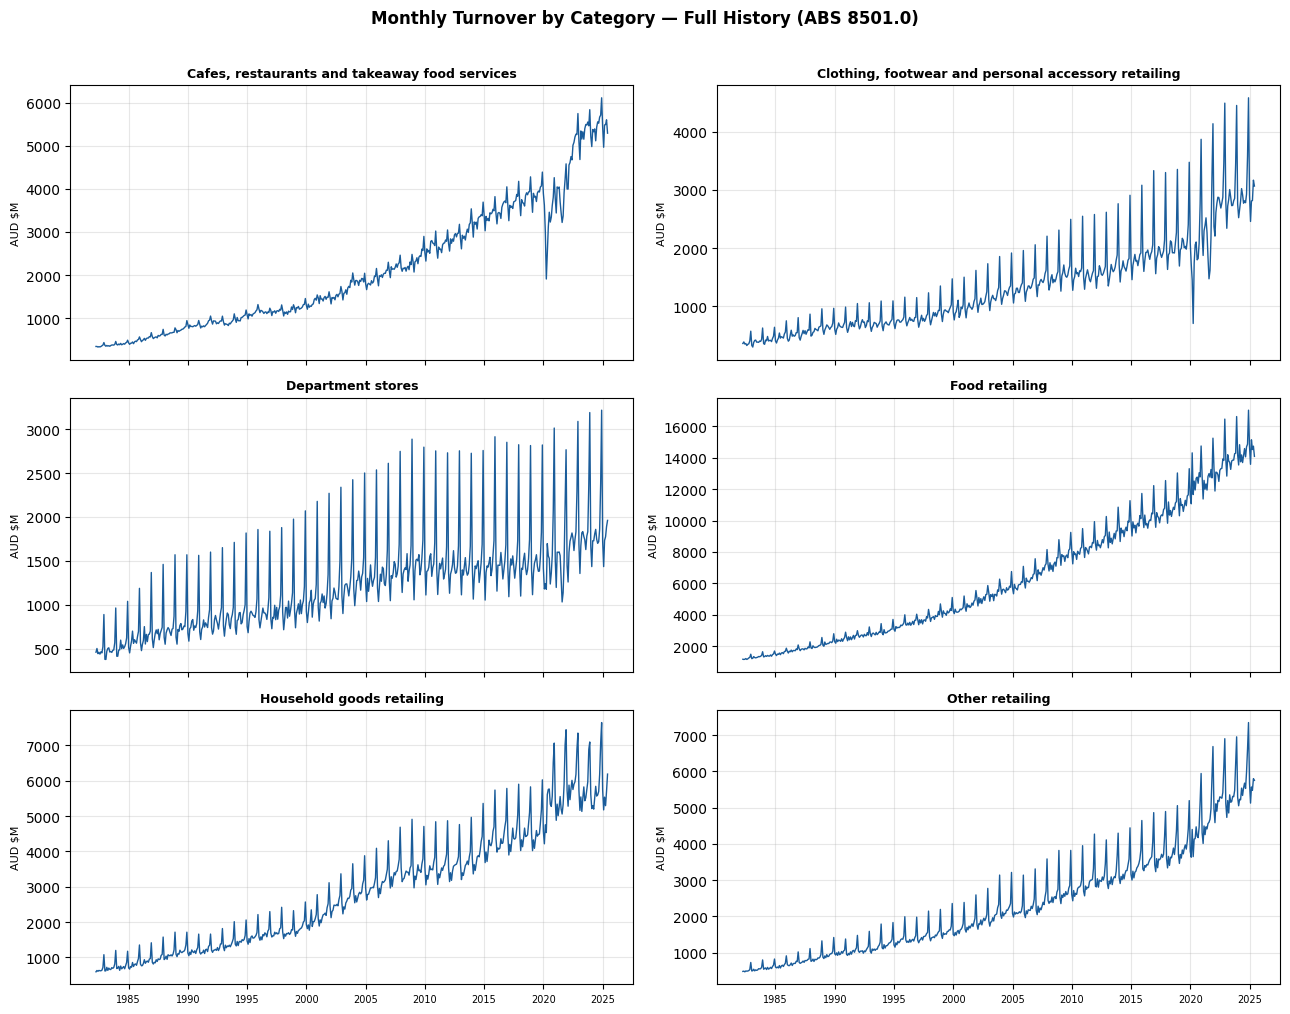

In [ ]:
# Plot all 6 categories on separate subplots to see each one's shape clearly
# This surfaces trends, structural changes, and anomalies for each category

categories = [c for c in df['category'].unique() if c != 'Total (Industry)']
fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharex=True)
axes = axes.flatten()
for i, cat in enumerate(sorted(categories)):
    data = df[df['category'] == cat].sort_values('date')
    axes[i].plot(data['date'], data['turnover_m'], linewidth=1, color='#1A5C9A')
    axes[i].set_title(cat, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('AUD $M', fontsize=8)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', labelsize=7)
fig.suptitle('Monthly Turnover by Category — Full History (ABS 8501.0)',
fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'output' / 'eda_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

### Seasonal Patterns

This analysis looks into the seasonality trends in the data, namely, whether numbers have consistently gone up or down in relation to the time of the year

Knowing these trends is vital in analysis because it guides how to treat monthly comparisons by providing more context into increasing or decreasing values

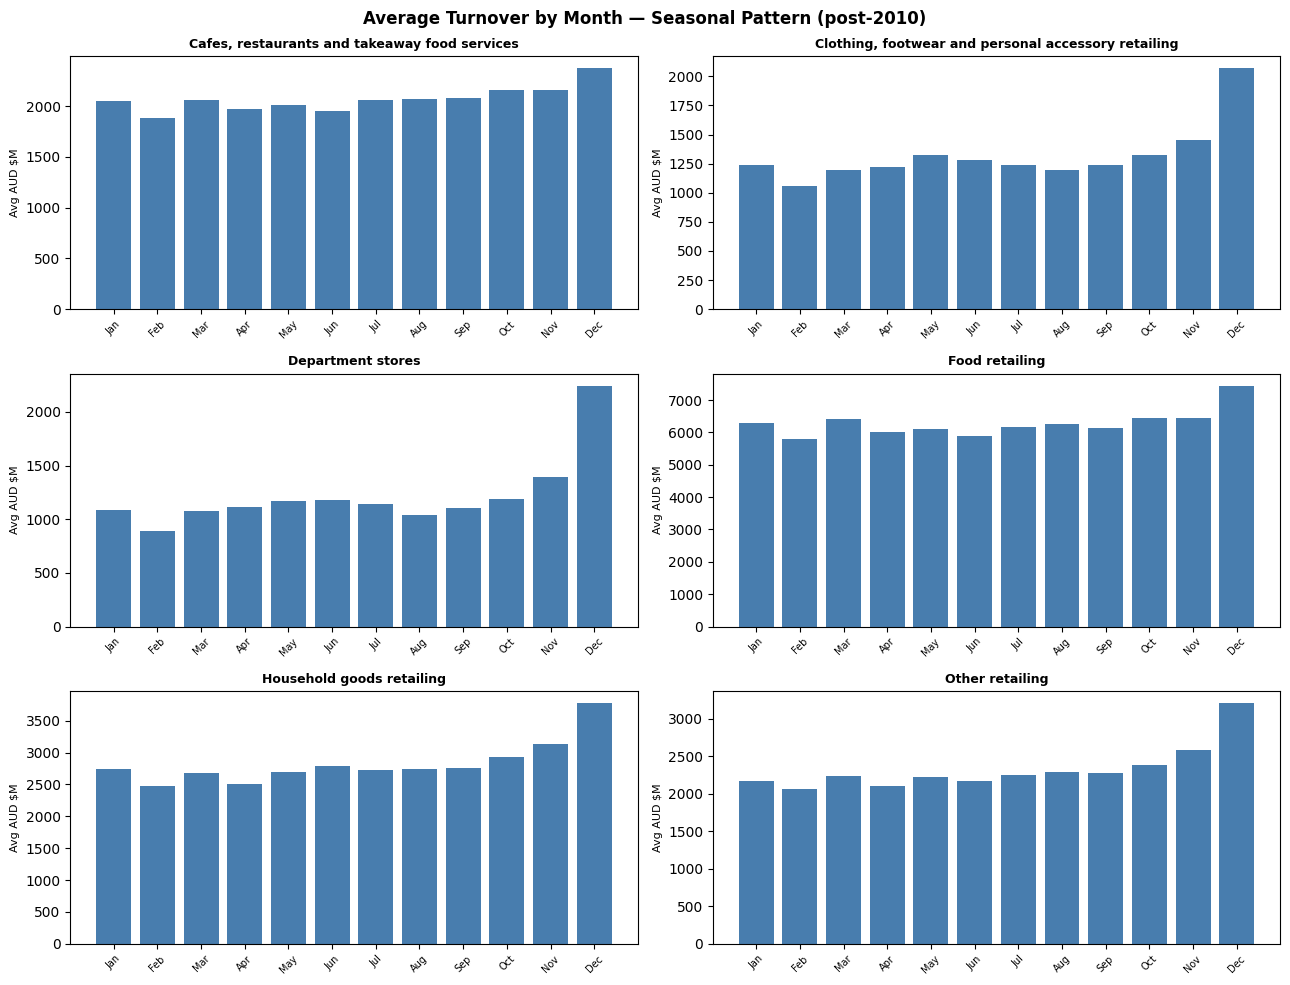

In [ ]:
import matplotlib.pyplot as plt

# Create dataframe containing the monthly averages by category (not including 2025)
monthly_avg = (
    df[(df['category'] != 'Total (Industry)') & (df['year'] < 2025)]
    .groupby(['category', 'month', 'month_name'])['turnover_m']
    .mean()
    .reset_index()
    .sort_values(['category', 'month'])
)

# Create the figure and axes
fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharey=False)
axes = axes.flatten()

# Populate the figure
for i, cat in enumerate(sorted(monthly_avg['category'].unique())):
    data = monthly_avg[monthly_avg['category'] == cat]
    axes[i].bar(data['month_name'], data['turnover_m'], color='#1A5C9A', alpha=0.8)
    axes[i].set_title(cat, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Avg AUD $M', fontsize=8)
    axes[i].tick_params(axis='x', labelsize=7, rotation=45)

# Label and stylize the figure
fig.suptitle('Average Turnover by Month — Seasonal Pattern (post-2010)',
fontsize=12, fontweight='bold')
plt.tight_layout()

# Save and show the figure
plt.savefig(PROJECT_ROOT / 'output' / 'eda_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

### Correlation Matrix

Identify whether categories are correlated to each other

High Correlation: Categories respond to similar macro forces, investment into one of these categories requires careful consideration of correlated categories to ensure high performance and success

Low Correlation: Cateogires are independent and investment into these categories do not require high consideration into other industry categories

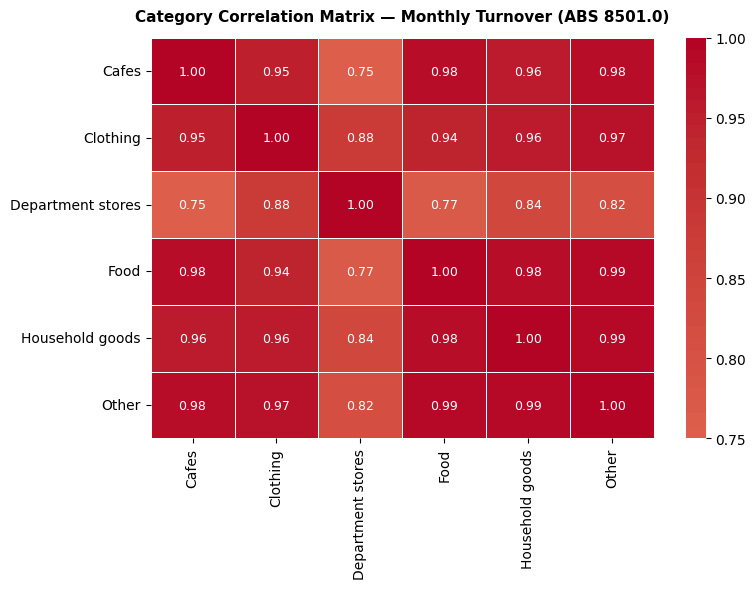

Most correlated category pairs:
Food             Other              0.99
Household goods  Other              0.99
Cafes            Food               0.98
                 Other              0.98
Food             Household goods    0.98
dtype: float64


In [ ]:
pivot = df[df['category'] != 'Total (Industry)'].pivot_table(index='date', columns='category', values='turnover_m')

# Shorten column names for readability on the heatmap
pivot.columns = [c.split(',')[0].replace('retailing','').strip() for c in pivot.columns]
corr = pivot.corr().round(2)
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,

linewidths=0.5, ax=ax, fmt='.2f', annot_kws={'size': 9})
ax.set_title('Category Correlation Matrix — Monthly Turnover (ABS 8501.0)',
fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'output' / 'eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the top correlated pairs
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
pairs = corr.where(mask).stack().sort_values(ascending=False)
print('Most correlated category pairs:')
print(pairs.head(5))